In [46]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
import os
import glob
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

palette = {'cmGC': '#c04744', 'ncmGC': "#e58e38", 'NGS': '#3171ae', 'GC': '#c04744'}

In [47]:
save_path = '/Users/harryclark/Documents/spatial-manifolds/data/xgboost_cell_number_assay_master.csv'

if os.path.exists(save_path):
    data = pd.read_csv(save_path)
    print(f'Loaded master data: {data.shape}')
else:
    data_source = '/Users/harryclark/Documents/data/xgboost_cell_number_assay/xgboost_cell_number_assay'
    files = glob.glob(os.path.join(data_source, '*.csv'))
    dfs = []
    for i, f in enumerate(files):
        try:
            df_tmp = pd.read_csv(f)
            if not df_tmp.empty:
                dfs.append(df_tmp)
        except Exception as e:
            print(f'Skipped {os.path.basename(f)}: {e}')
        if (i + 1) % 50 == 0:
            print(f'  {i+1}/{len(files)} files read...')
    data = pd.concat(dfs, ignore_index=True)
    data.to_csv(save_path, index=False)
    print(f'Saved master data: {data.shape} -> {save_path}')

print('Baselines:', sorted(data['baseline'].unique()))

Loaded master data: (1118222, 8)
Baselines: ['lfp', 'pos', 'pos_lfp', 'pos_speed', 'pos_speed_lfp', 'speed', 'speed_lfp']


In [48]:
import pandas as pd

# ── Load ─────────────────────────────────────────────────────────────────────
data = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/xgboost_cell_number_assay_master.csv')
cell_class = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')

# ── Normalise types so joins work ────────────────────────────────────────────
cell_class['mouse']      = cell_class['mouse'].astype(int)
cell_class['day']        = cell_class['day'].astype(int)
cell_class['cluster_id'] = cell_class['cluster_id'].astype(int)

xg_cells = (
    data[['mouse', 'day', 'target_cluster_id']]
    .drop_duplicates()
    .rename(columns={'target_cluster_id': 'cluster_id'})
)

# ── Find cells present in classifications but absent from xgboost data ────────
merged = cell_class.merge(xg_cells, on=['mouse', 'day', 'cluster_id'], how='left', indicator=True)
missing = merged[merged['_merge'] == 'left_only'].copy()

# ── Summary ──────────────────────────────────────────────────────────────────
print(f"Cells in cell_classifications:  {len(cell_class)}")
print(f"Unique cells in xgboost data:   {len(xg_cells)}")
print(f"Missing from xgboost data:      {len(missing)}")

print("\n── Missing by cell type ─────────────────────────────────────────────────")
print(missing['cell_type'].value_counts().to_string())

print("\n── Missing by mouse / day ───────────────────────────────────────────────")
by_session = (
    missing.groupby(['mouse', 'day'])
    .agg(n_missing=('cluster_id', 'count'),
         cell_types=('cell_type', lambda x: ', '.join(sorted(x.value_counts().index))))
    .reset_index()
    .sort_values(['mouse', 'day'])
)
print(by_session.to_string(index=False))

print("\n── Full list of missing cells ───────────────────────────────────────────")
missing_detail = (
    missing[['mouse', 'day', 'cluster_id', 'cell_type']]
    .sort_values(['mouse', 'day', 'cluster_id'])
    .reset_index(drop=True)
)
display(missing_detail)


Cells in cell_classifications:  8916
Unique cells in xgboost data:   7611
Missing from xgboost data:      703

── Missing by cell type ─────────────────────────────────────────────────
cell_type
NG       422
Other    216
GC        65

── Missing by mouse / day ───────────────────────────────────────────────
 mouse  day  n_missing    cell_types
    20   14         60     NG, Other
    20   19         23     NG, Other
    21   20         18        GC, NG
    21   21         24 GC, NG, Other
    21   22         18        GC, NG
    21   23         18        GC, NG
    21   26         40     NG, Other
    22   36         37 GC, NG, Other
    22   37         30     NG, Other
    22   38         14            NG
    25   16         11     NG, Other
    25   18         33        GC, NG
    25   20         27 GC, NG, Other
    25   24         19 GC, NG, Other
    28   20         60 GC, NG, Other
    28   23         34     NG, Other
    28   25        145 GC, NG, Other
    29   17         34   

,mouse,day,cluster_id,cell_type
0,20,14,279,NG
1,20,14,284,NG
2,20,14,285,NG
3,20,14,286,NG
4,20,14,287,NG
...,...,...,...,...
698,29,25,45,NG
699,29,25,47,GC
700,29,25,50,NG
701,29,25,61,NG


In [49]:
# ── Helper functions ──────────────────────────────────────────────────────────

def make_random_data(data, baseline):
    """Process raw data for a given baseline, returning (random_data, random_data_ngs)."""
    df = data[data['baseline'] == baseline].copy()
    df = df.rename(columns={
        'target_cluster_id': 'cluster_id',
        'n_covariate_cells':  'n_neurons',
        'pR2_cv':             'pR2'
    })
    # Infer target cell type from which covariate_types appear for each cluster
    cluster_cov = (
        df.groupby(['mouse', 'day', 'cluster_id'])['covariate_type']
        .apply(lambda x: set(x.unique()))
        .reset_index()
    )
    def infer_target(cov_set):
        if 'cmGC'  in cov_set: return 'cmGC'
        if 'ncmGC' in cov_set: return 'ncmGC'
        return 'NGS'
    cluster_cov['target_type'] = cluster_cov['covariate_type'].apply(infer_target)
    df = df.merge(cluster_cov[['mouse', 'day', 'cluster_id', 'target_type']],
                  on=['mouse', 'day', 'cluster_id'])
    df['tested_on'] = df['target_type']
    df['trained_on'] = df['covariate_cell_type']
    # For NGS covariate analysis: co-modularity only applies when GC cells are
    # the covariate, so target GC cells are classified simply as GC (not cm/ncm)
    df_ngs = df.copy()
    df_ngs.loc[df_ngs['tested_on'].isin(['cmGC', 'ncmGC']), 'tested_on'] = 'GC'
    return df, df_ngs


def subset_by_n_neurons(df, trained_on='GC', n_neurons=5):
    df = df[df['trained_on'] == trained_on]
    df['mouse_day_cluster_id'] = (df['mouse'].astype(str) + '_' +
                                   df['day'].astype(str) + '_' +
                                   df['cluster_id'].astype(str))
    ids_ok = df[df['n_neurons'] >= n_neurons]['mouse_day_cluster_id'].unique()
    df = df[df['mouse_day_cluster_id'].isin(ids_ok)]
    return df[df['n_neurons'] <= n_neurons]


vc = {'day': '0 + C(day)', 'cluster': '0 + C(cluster_id)'}

def compute_added_pR2_max(df, trained_on, tested_on_groups):
    records = []
    for tested_on in tested_on_groups:
        df_plot = df[
            (df['trained_on'] == trained_on) &
            (df['tested_on']  == tested_on) &
            df['n_neurons'].notna()
        ].copy()
        pivot = df_plot.pivot_table(
            index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2'
        )
        for idx, row in pivot.dropna(subset=[0]).iterrows():
            nonzero = [c for c in row.index if c != 0 and not pd.isna(row[c])]
            if not nonzero: continue
            max_n = max(nonzero)
            records.append({'added_pR2': row[max_n] - row[0], 'tested_on': tested_on,
                            'mouse': idx[0], 'day': idx[1], 'cluster_id': idx[2]})
    return pd.DataFrame(records)


def pairwise_lmm(df, groups):
    pvals = {}
    for i, g1 in enumerate(groups):
        for g2 in groups[i+1:]:
            temp = df[df['tested_on'].isin([g1, g2])].copy()
            temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[g1, g2], ordered=True)
            res = smf.mixedlm('added_pR2 ~ tested_on', temp,
                              groups=temp['mouse'], vc_formula=vc).fit()
            pvals[(g1, g2)] = res.pvalues.get(f'tested_on[T.{g2}]', np.nan)
    return pvals


def zero_pvals_lmm(df, groups):
    zpvals = {}
    for ref in groups:
        temp = df.copy()
        temp['tested_on'] = pd.Categorical(
            temp['tested_on'],
            categories=[ref] + [g for g in groups if g != ref],
            ordered=True
        )
        res = smf.mixedlm('added_pR2 ~ tested_on', temp,
                          groups=temp['mouse'], vc_formula=vc).fit()
        zpvals[ref] = res.pvalues['Intercept']
    return zpvals


def add_sig_bars(ax, groups, pvals, y_start, step):
    for idx, ((g1, g2), pval) in enumerate(pvals.items()):
        x1, x2 = groups.index(g1), groups.index(g2)
        y = y_start + idx * step
        ax.plot([x1, x1, x2, x2], [y, y+0.002, y+0.002, y], lw=1, c='k')
        ax.text((x1+x2)/2, y+0.002, f'p = {pval:.2g}', ha='center', va='bottom', fontsize=8)

In [50]:
# Baseline display labels and run order
baseline_labels = {
    'pos':           'Position',
    'speed':         'Speed',
    'lfp':           'LFP',
    'pos_speed':     'Position + Speed',
    'pos_lfp':       'Position + LFP',
    'speed_lfp':     'Speed + LFP',
    'pos_speed_lfp': 'Position + Speed + LFP',
}

# Set to True to run LMMs (slow: ~30-60 s per baseline per covariate type)
run_lmm = True

out_dir = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/baselines'
os.makedirs(out_dir, exist_ok=True)

gc_groups  = ['cmGC', 'ncmGC', 'NGS']
ngs_groups = ['GC', 'NGS']
max_n      = 10

print(f'Output: {out_dir}')

Output: /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/baselines



  Baseline: Position


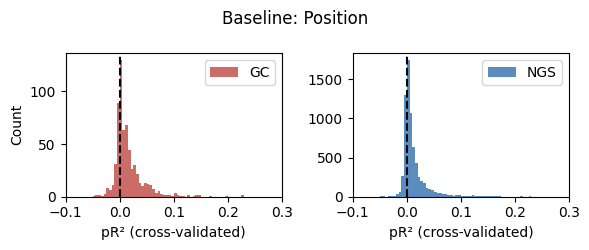

  Running LMMs...


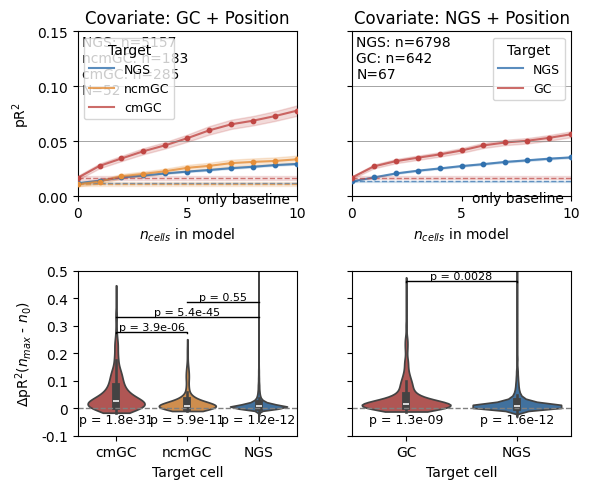

  Saved: pos_histogram.pdf, pos_2x2_line_violin.pdf

  Baseline: Speed


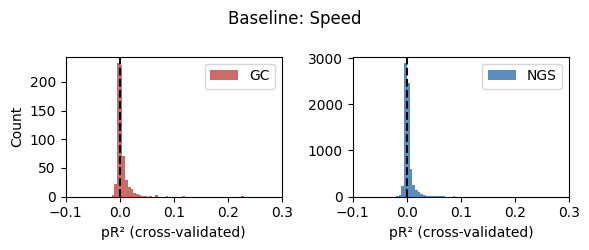

  Running LMMs...


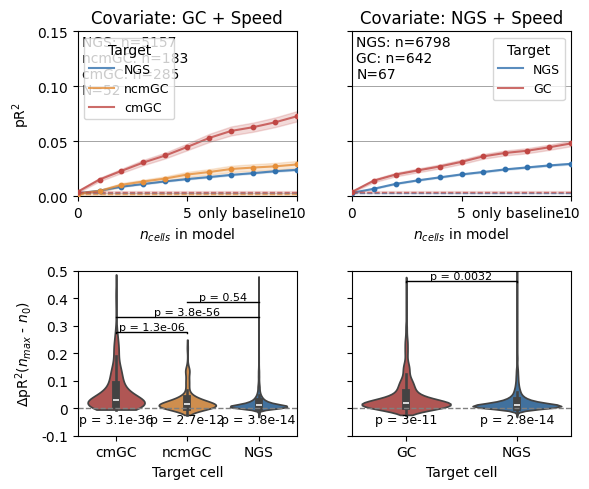

  Saved: speed_histogram.pdf, speed_2x2_line_violin.pdf

  Baseline: LFP


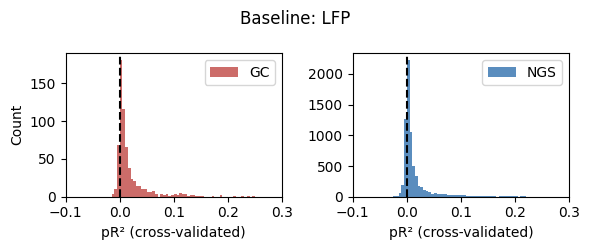

  Running LMMs...


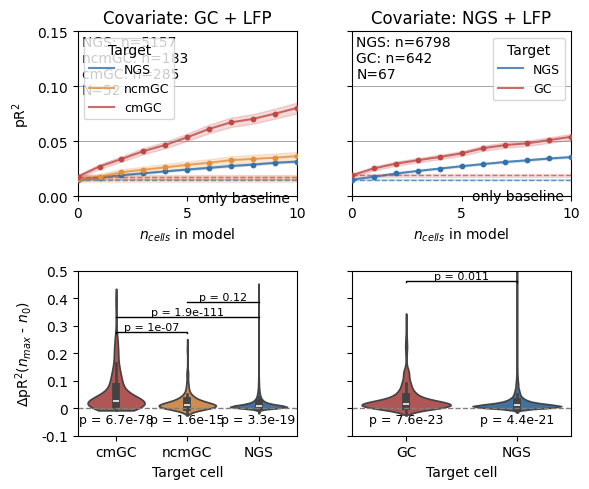

  Saved: lfp_histogram.pdf, lfp_2x2_line_violin.pdf

  Baseline: Position + Speed


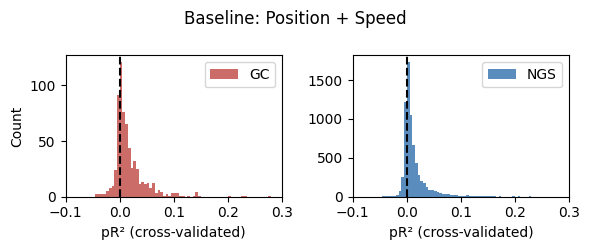

  Running LMMs...


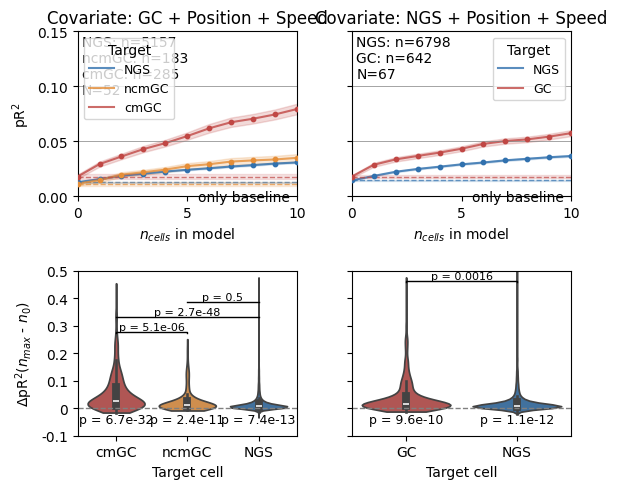

  Saved: pos_speed_histogram.pdf, pos_speed_2x2_line_violin.pdf

  Baseline: Position + LFP


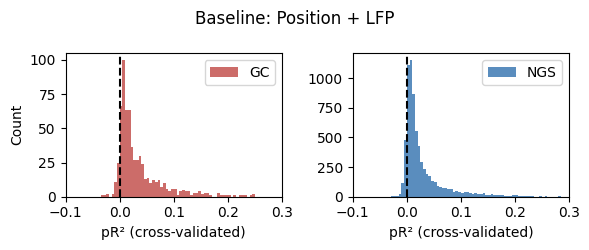

  Running LMMs...


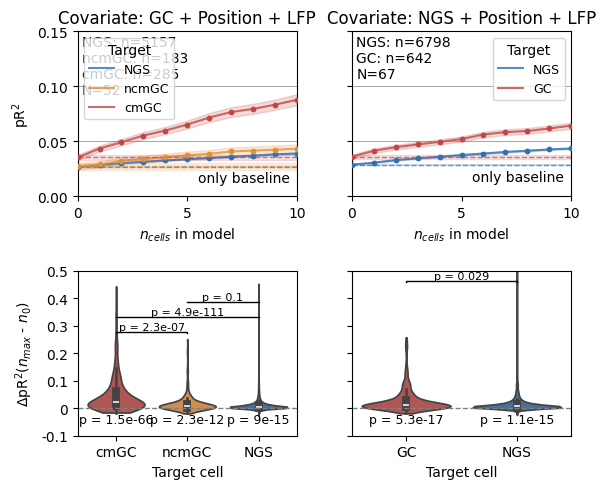

  Saved: pos_lfp_histogram.pdf, pos_lfp_2x2_line_violin.pdf

  Baseline: Speed + LFP


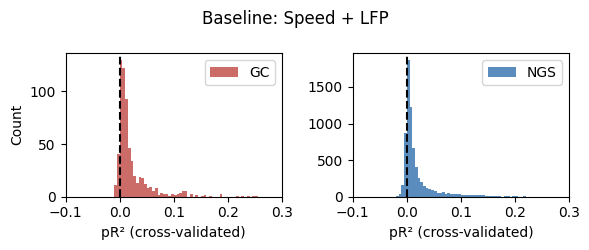

  Running LMMs...


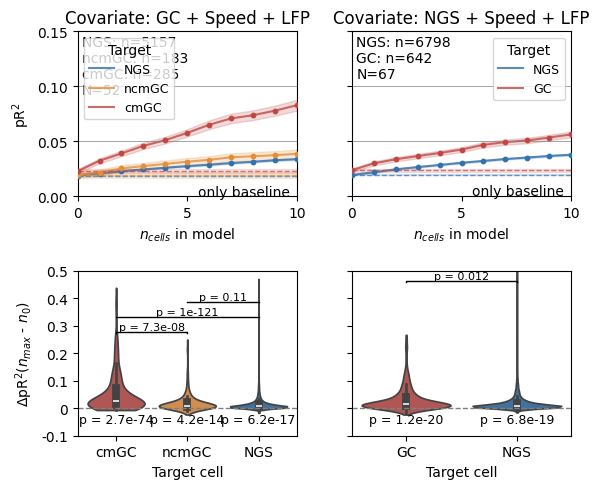

  Saved: speed_lfp_histogram.pdf, speed_lfp_2x2_line_violin.pdf

  Baseline: Position + Speed + LFP


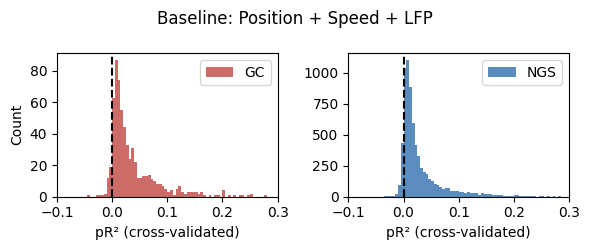

  Running LMMs...


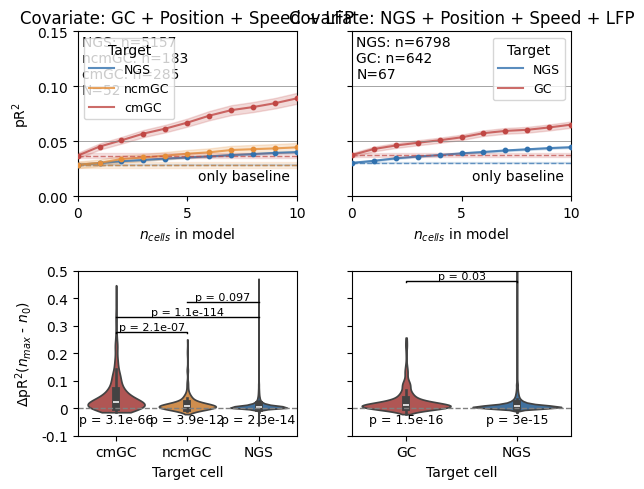

  Saved: pos_speed_lfp_histogram.pdf, pos_speed_lfp_2x2_line_violin.pdf

Done.


In [51]:
all_lmm_results = {}

for baseline, label in baseline_labels.items():
    print(f'\n{"="*60}\n  Baseline: {label}\n{"="*60}')

    random_data, random_data_ngs = make_random_data(data, baseline)

    # ── Plot 1: baseline pR2 histogram (2 col, 1 row) ────────────────────────
    baseline_df = (
        random_data[random_data['n_neurons'] == 0]
        .drop_duplicates(subset=['mouse', 'day', 'cluster_id'])
        .reset_index(drop=True)
    )
    gc_data  = baseline_df[baseline_df['tested_on'].isin(['cmGC', 'ncmGC'])]
    ngs_data = baseline_df[baseline_df['tested_on'] == 'NGS']

    fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))
    axes[0].hist(gc_data['pR2'],  bins=80, range=[-0.1, 0.3], alpha=0.8, color='#c04744', label='GC')
    axes[0].set_xlabel('pR\u00b2 (cross-validated)')
    axes[0].set_ylabel('Count')
    axes[0].axvline(x=0, color='k', linestyle='--')
    axes[0].set_xlim([-0.1, 0.3])
    axes[0].legend()
    axes[1].hist(ngs_data['pR2'], bins=80, range=[-0.1, 0.3], alpha=0.8, color='#3171ae', label='NGS')
    axes[1].set_xlabel('pR\u00b2 (cross-validated)')
    axes[1].axvline(x=0, color='k', linestyle='--')
    axes[1].set_xlim([-0.1, 0.3])
    axes[1].legend()
    plt.suptitle(f'Baseline: {label}')
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f'{baseline}_histogram.pdf'), dpi=300)
    plt.show()

    # ── Delta pR2 (max n) ─────────────────────────────────────────────────────
    added_gc_max  = compute_added_pR2_max(random_data,     'GC',  gc_groups)
    added_ngs_max = compute_added_pR2_max(random_data_ngs, 'NGS', ngs_groups)

    # ── LMM p-values ─────────────────────────────────────────────────────────
    if run_lmm:
        print('  Running LMMs...')
        pvals_gc       = pairwise_lmm(added_gc_max,  gc_groups)
        gc_zero_pvals  = zero_pvals_lmm(added_gc_max,  gc_groups)
        pvals_ngs      = pairwise_lmm(added_ngs_max, ngs_groups)
        ngs_zero_pvals = zero_pvals_lmm(added_ngs_max, ngs_groups)
    else:
        pvals_gc       = {(g1,g2): np.nan for i,g1 in enumerate(gc_groups)  for g2 in gc_groups[i+1:]}
        gc_zero_pvals  = {g: np.nan for g in gc_groups}
        pvals_ngs      = {(g1,g2): np.nan for i,g1 in enumerate(ngs_groups) for g2 in ngs_groups[i+1:]}
        ngs_zero_pvals = {g: np.nan for g in ngs_groups}

    all_lmm_results[baseline] = {
        'pvals_gc': pvals_gc, 'gc_zero': gc_zero_pvals,
        'pvals_ngs': pvals_ngs, 'ngs_zero': ngs_zero_pvals,
    }

    # ── Plot 2: 2x2 line (top) + violin (bottom) ─────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(6, 5), sharey='row')

    def line_ax(ax, df, trained_on, ylabel=False):
        vd = subset_by_n_neurons(df, n_neurons=max_n, trained_on=trained_on)
        if vd.empty:
            ax.axis('off'); return
        ann, y0_list = [], []
        for to in vd['tested_on'].unique():
            dp = vd[(vd['trained_on'] == trained_on) & (vd['tested_on'] == to)]
            if dp.empty: continue
            pivot = dp.pivot_table(
                index=['mouse','day','cluster_id'], columns='n_neurons', values='pR2'
            ).sort_index(axis=1)
            mean = pivot.mean(axis=0); sem = pivot.sem(axis=0)
            col = palette.get(to)
            mean, sem = mean[mean.index <= max_n], sem[sem.index <= max_n]
            ax.plot(mean.index, mean.values, label=to, alpha=0.8, color=col)
            ax.scatter(mean.index, mean.values, s=10, color=col, zorder=3)
            ax.fill_between(mean.index, mean-sem, mean+sem, alpha=0.2, color=col)
            if 0 in pivot.columns:
                y0, y0s = mean.loc[0], sem.loc[0]
                y0_list.append(y0)
                ax.axhline(y0, linestyle='dashed', color=col, linewidth=1, alpha=0.7)
                ax.fill_between([0, max_n], y0-y0s, y0+y0s, color=col, alpha=0.15, zorder=2)
            ann.append(f'{to}: n={len(dp[dp["n_neurons"]==1])}')
        ann.append(f'N={vd[["mouse","day"]].drop_duplicates().shape[0]}')
        ax.text(0.02, 0.98, '\n'.join(ann), ha='left', va='top',
                transform=ax.transAxes, fontsize=10, color='k')
        for yr in [0.05, 0.1, 0.15]:
            ax.axhline(yr, linestyle='solid', color='grey', linewidth=0.5)
        ax.set_xlim(0, max_n); ax.set_ylim(0, 0.15)
        ax.set_xticks([0, 5, 10]); ax.set_yticks([0, 0.05, 0.1, 0.15])
        ax.set_xlabel('$n_{cells}$ in model')
        if ylabel: ax.set_ylabel('pR$^2$')
        ax.legend(title='Target', fontsize=9)
        if y0_list:
            ax.annotate('only baseline', xy=(max_n, max(y0_list)), xycoords='data',
                        xytext=(-5, -20), textcoords='offset points',
                        ha='right', va='bottom', fontsize=10, color='k')

    def violin_ax(ax, df, groups, pvals, zpvals, ylim=(-0.075, 0.5),
                  y_sig=0.275, step=0.055):
        sns.violinplot(x='tested_on', y='added_pR2', data=df,
                       inner='box', cut=0, palette=palette, ax=ax)
        ax.axhline(0, color='gray', linestyle='--', linewidth=1)
        ax.set_ylabel('$\\Delta$pR$^2$($n_{10}$ - $n_{0}$)')
        ax.set_xlabel('Target cell'); ax.set_title('')
        ax.set_ylim(*ylim)
        ax.set_yticks([-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5])
        ax.set_yticklabels(['-0.1', '0', '0.1', '0.2', '0.3', '0.4', '0.5'])
        add_sig_bars(ax, groups, pvals, y_start=y_sig, step=step)
        for i, g in enumerate(groups):
            ax.text(i, ylim[0]+0.01, f'p = {zpvals[g]:.2g}',
                    ha='center', va='bottom', fontsize=9)

    line_ax(axes[0, 0], random_data,     'GC',  ylabel=True)
    axes[0, 0].set_title(f'Covariate: GC + {label}')
    line_ax(axes[0, 1], random_data_ngs, 'NGS')
    axes[0, 1].set_title(f'Covariate: NGS + {label}')
    violin_ax(axes[1, 0], added_gc_max,  gc_groups,  pvals_gc,  gc_zero_pvals)
    violin_ax(axes[1, 1], added_ngs_max, ngs_groups, pvals_ngs, ngs_zero_pvals,
              y_sig=0.46, step=0.03)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.25, hspace=0.45)
    plt.savefig(os.path.join(out_dir, f'{baseline}_2x2_line_violin.pdf'), bbox_inches='tight')
    plt.show()

    print(f'  Saved: {baseline}_histogram.pdf, {baseline}_2x2_line_violin.pdf')

print('\nDone.')


  Baseline: Position
  Running LMMs...


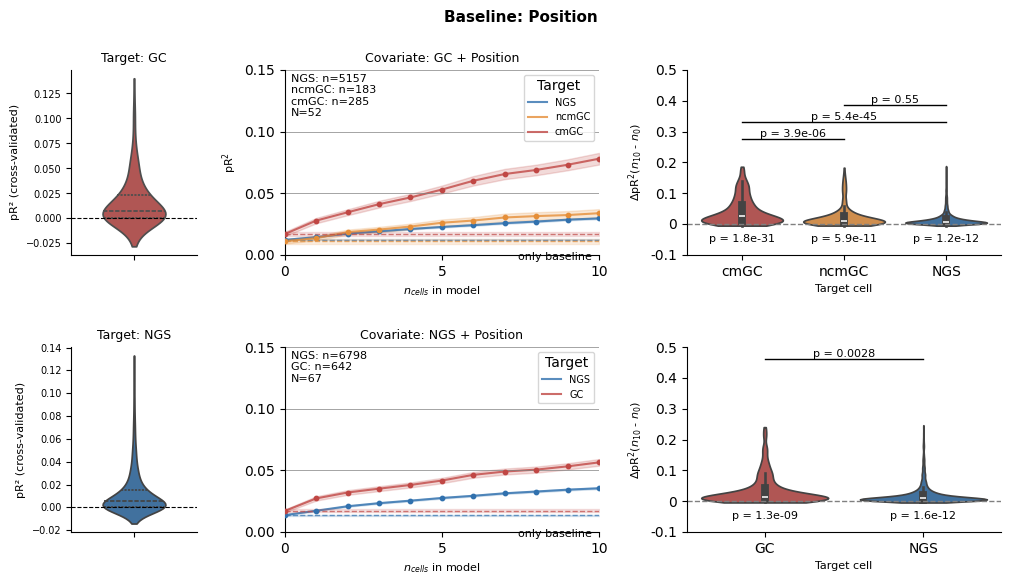

  Saved: pos_2x3_summary.pdf

  Baseline: Speed
  Running LMMs...


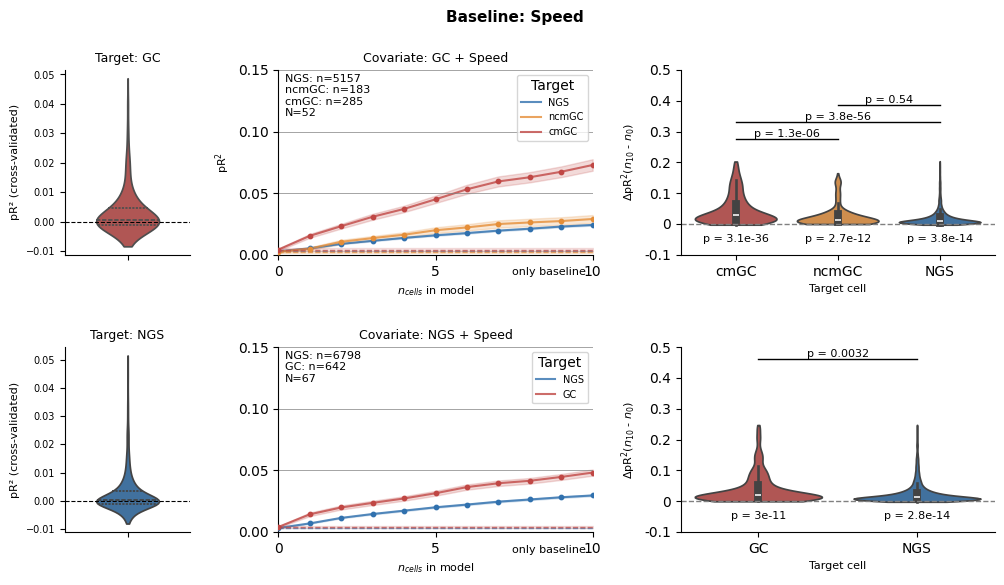

  Saved: speed_2x3_summary.pdf

  Baseline: LFP
  Running LMMs...


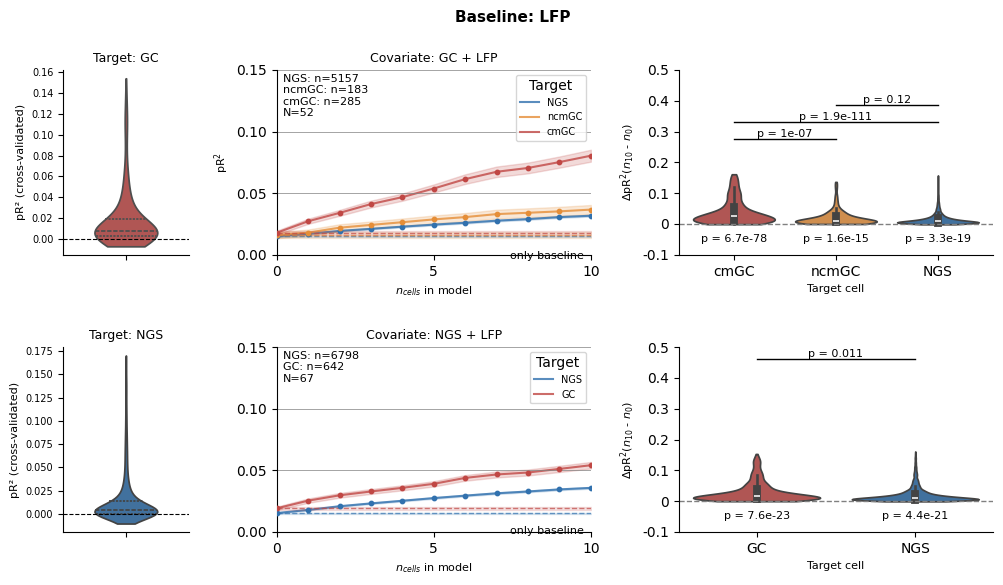

  Saved: lfp_2x3_summary.pdf

  Baseline: Pos+Speed
  Running LMMs...


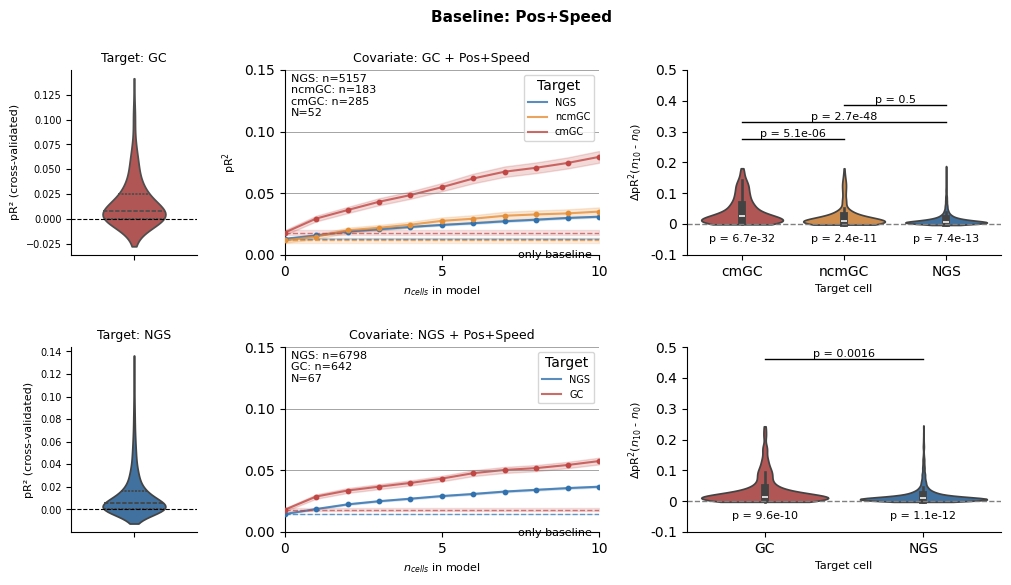

  Saved: pos_speed_2x3_summary.pdf

  Baseline: Pos+LFP
  Running LMMs...


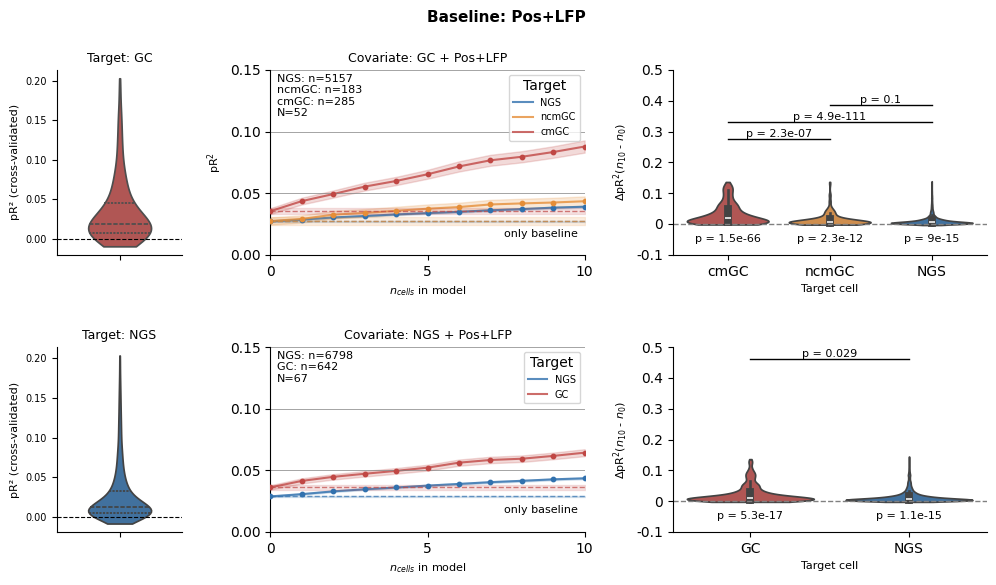

  Saved: pos_lfp_2x3_summary.pdf

  Baseline: Spd+LFP
  Running LMMs...


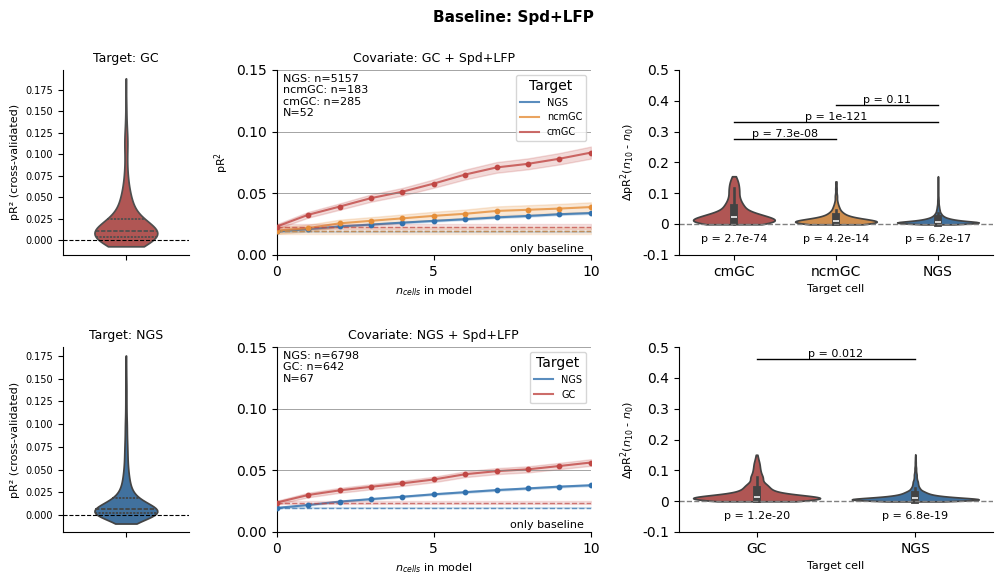

  Saved: speed_lfp_2x3_summary.pdf

  Baseline: Pos+Spd+LFP
  Running LMMs...


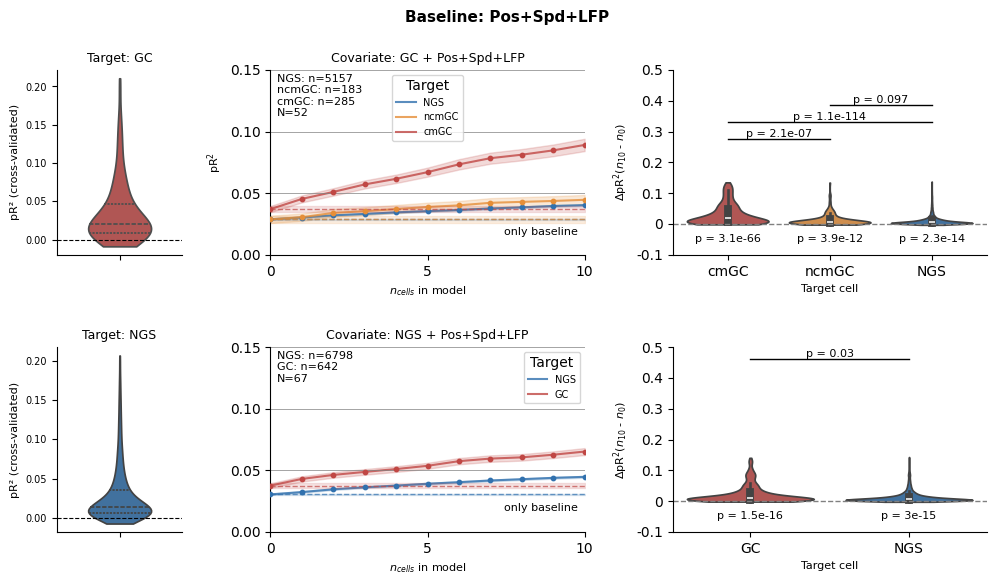

  Saved: pos_speed_lfp_2x3_summary.pdf

Done.


In [61]:
import matplotlib.gridspec as gridspec

all_lmm_results = {}

for baseline, label in baseline_labels.items():
    print(f'\n{"="*60}\n  Baseline: {label}\n{"="*60}')

    random_data, random_data_ngs = make_random_data(data, baseline)

    # ── baseline n=0 data ─────────────────────────────────────────────────────
    baseline_df = (
        random_data[random_data['n_neurons'] == 0]
        .drop_duplicates(subset=['mouse', 'day', 'cluster_id'])
        .reset_index(drop=True)
    )
    gc_data  = baseline_df[baseline_df['tested_on'].isin(['cmGC', 'ncmGC'])]
    ngs_data = baseline_df[baseline_df['tested_on'] == 'NGS']

    # ── Delta pR2 (max n) ─────────────────────────────────────────────────────
    added_gc_max  = compute_added_pR2_max(random_data,     'GC',  gc_groups)
    added_ngs_max = compute_added_pR2_max(random_data_ngs, 'NGS', ngs_groups)

    # ── LMM p-values (use unclipped data) ────────────────────────────────────
    if run_lmm:
        print('  Running LMMs...')
        pvals_gc       = pairwise_lmm(added_gc_max,  gc_groups)
        gc_zero_pvals  = zero_pvals_lmm(added_gc_max,  gc_groups)
        pvals_ngs      = pairwise_lmm(added_ngs_max, ngs_groups)
        ngs_zero_pvals = zero_pvals_lmm(added_ngs_max, ngs_groups)
    else:
        pvals_gc       = {(g1,g2): np.nan for i,g1 in enumerate(gc_groups)  for g2 in gc_groups[i+1:]}
        gc_zero_pvals  = {g: np.nan for g in gc_groups}
        pvals_ngs      = {(g1,g2): np.nan for i,g1 in enumerate(ngs_groups) for g2 in ngs_groups[i+1:]}
        ngs_zero_pvals = {g: np.nan for g in ngs_groups}

    all_lmm_results[baseline] = {
        'pvals_gc': pvals_gc, 'gc_zero': gc_zero_pvals,
        'pvals_ngs': pvals_ngs, 'ngs_zero': ngs_zero_pvals,
    }

    # ── Clip to 1st–99th percentile for visualisation only ───────────────────
    def clip_pct(df, col):
        lo, hi = df[col].quantile(0.01), df[col].quantile(0.99)
        return df[df[col].between(lo, hi)]

    gc_data_plot  = clip_pct(gc_data,  'pR2')
    ngs_data_plot = clip_pct(ngs_data, 'pR2')

    # ── 2×3 figure ────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(12, 6))
    gs  = gridspec.GridSpec(2, 3, figure=fig, width_ratios=[0.4,1,1], hspace=0.5, wspace=0.35)
    fig.suptitle(f'Baseline: {label}', fontsize=11, fontweight='bold')

    ax_hist_gc  = fig.add_subplot(gs[0, 0])
    ax_hist_ngs = fig.add_subplot(gs[1, 0])
    ax_line_gc  = fig.add_subplot(gs[0, 1])
    ax_line_ngs = fig.add_subplot(gs[1, 1], sharey=ax_line_gc)
    ax_vln_gc   = fig.add_subplot(gs[0, 2])
    ax_vln_ngs  = fig.add_subplot(gs[1, 2])

    # ── Col 0: baseline pR2 violin plots (clipped for display) ───────────────
    sns.violinplot(data=gc_data_plot, y='pR2', ax=ax_hist_gc,
                   color='#c04744', inner='quartile', cut=0, width=0.5, bw_adjust=1.5)
    ax_hist_gc.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax_hist_gc.set_xlabel('')
    ax_hist_gc.set_ylabel('pR² (cross-validated)', fontsize=8)
    ax_hist_gc.set_title('Target: GC', fontsize=9)
    ax_hist_gc.tick_params(labelsize=7)
    ax_hist_gc.spines['top'].set_visible(False)
    ax_hist_gc.spines['right'].set_visible(False)

    sns.violinplot(data=ngs_data_plot, y='pR2', ax=ax_hist_ngs,
                   color='#3171ae', inner='quartile', cut=0, width=0.5, bw_adjust=1.5)
    ax_hist_ngs.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax_hist_ngs.set_xlabel('')
    ax_hist_ngs.set_ylabel('pR² (cross-validated)', fontsize=8)
    ax_hist_ngs.set_title('Target: NGS', fontsize=9)
    ax_hist_ngs.tick_params(labelsize=7)
    ax_hist_ngs.spines['top'].set_visible(False)
    ax_hist_ngs.spines['right'].set_visible(False)

    # ── Col 1: pR2 vs n_neurons line plots ────────────────────────────────────
    def line_ax(ax, df, trained_on, ylabel=False):
        vd = subset_by_n_neurons(df, n_neurons=max_n, trained_on=trained_on)
        if vd.empty:
            ax.axis('off'); return
        ann, y0_list = [], []
        for to in vd['tested_on'].unique():
            dp = vd[(vd['trained_on'] == trained_on) & (vd['tested_on'] == to)]
            if dp.empty: continue
            pivot = dp.pivot_table(
                index=['mouse','day','cluster_id'], columns='n_neurons', values='pR2'
            ).sort_index(axis=1)
            mean = pivot.mean(axis=0); sem = pivot.sem(axis=0)
            col  = palette.get(to)
            mean, sem = mean[mean.index <= max_n], sem[sem.index <= max_n]
            ax.plot(mean.index, mean.values, label=to, alpha=0.8, color=col)
            ax.scatter(mean.index, mean.values, s=10, color=col, zorder=3)
            ax.fill_between(mean.index, mean-sem, mean+sem, alpha=0.2, color=col)
            if 0 in pivot.columns:
                y0, y0s = mean.loc[0], sem.loc[0]
                y0_list.append(y0)
                ax.axhline(y0, linestyle='dashed', color=col, linewidth=1, alpha=0.7)
                ax.fill_between([0, max_n], y0-y0s, y0+y0s, color=col, alpha=0.15, zorder=2)
            ann.append(f'{to}: n={len(dp[dp["n_neurons"]==1])}')
        ann.append(f'N={vd[["mouse","day"]].drop_duplicates().shape[0]}')
        ax.text(0.02, 0.98, '\n'.join(ann), ha='left', va='top',
                transform=ax.transAxes, fontsize=8, color='k')
        for yr in [0.05, 0.1, 0.15]:
            ax.axhline(yr, linestyle='solid', color='grey', linewidth=0.5)
        ax.set_xlim(0, max_n); ax.set_ylim(0, 0.15)
        ax.set_xticks([0, 5, 10]); ax.set_yticks([0, 0.05, 0.1, 0.15])
        ax.set_xlabel('$n_{cells}$ in model', fontsize=8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if ylabel: ax.set_ylabel('pR$^2$', fontsize=8)
        ax.legend(title='Target', fontsize=7)
        if y0_list:
            ax.annotate('only baseline', xy=(max_n, max(y0_list)), xycoords='data',
                        xytext=(-5, -20), textcoords='offset points',
                        ha='right', va='bottom', fontsize=8, color='k')

    line_ax(ax_line_gc,  random_data,     'GC',  ylabel=True)
    ax_line_gc.set_title(f'Covariate: GC + {label}', fontsize=9)
    line_ax(ax_line_ngs, random_data_ngs, 'NGS')
    ax_line_ngs.set_title(f'Covariate: NGS + {label}', fontsize=9)

    # ── Col 2: delta pR2 violin plots (clipped for display, stats use full data)
    def violin_ax(ax, df, groups, pvals, zpvals, ylim=(-0.075, 0.5),
                  y_sig=0.275, step=0.055):
        df_plot = clip_pct(df, 'added_pR2')
        sns.violinplot(x='tested_on', y='added_pR2', data=df_plot,
                       inner='box', cut=0, palette=palette, ax=ax)
        ax.axhline(0, color='gray', linestyle='--', linewidth=1)
        ax.set_ylabel('$\\Delta$pR$^2$($n_{10}$ - $n_{0}$)', fontsize=8)
        ax.set_xlabel('Target cell', fontsize=8)
        ax.set_title('')
        ax.set_ylim(*ylim)
        ax.set_yticks([-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5])
        ax.set_yticklabels(['-0.1', '0', '0.1', '0.2', '0.3', '0.4', '0.5'])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        add_sig_bars(ax, groups, pvals, y_start=y_sig, step=step)
        for i, g in enumerate(groups):
            ax.text(i, ylim[0]+0.01, f'p = {zpvals[g]:.2g}',
                    ha='center', va='bottom', fontsize=8)

    violin_ax(ax_vln_gc,  added_gc_max,  gc_groups,  pvals_gc,  gc_zero_pvals)
    violin_ax(ax_vln_ngs, added_ngs_max, ngs_groups, pvals_ngs, ngs_zero_pvals,
              y_sig=0.46, step=0.03)

    plt.savefig(os.path.join(out_dir, f'{baseline}_2x3_summary.pdf'),
                bbox_inches='tight', dpi=300)
    plt.show()
    print(f'  Saved: {baseline}_2x3_summary.pdf')

print('\nDone.')


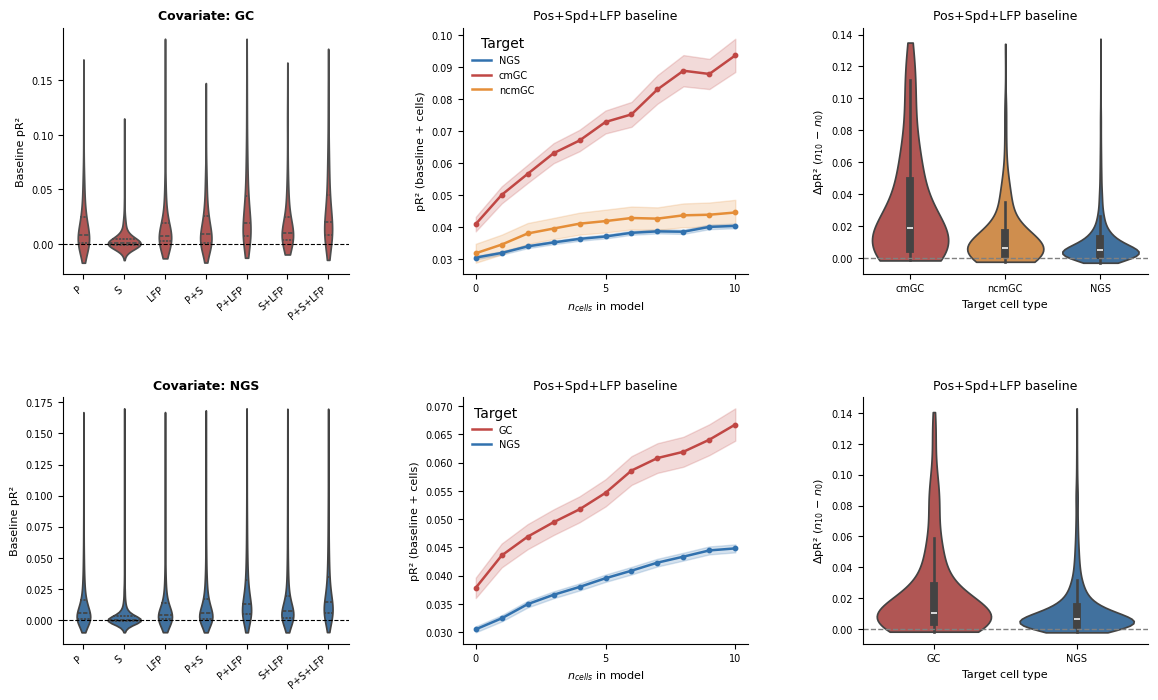

In [66]:
import matplotlib.gridspec as gridspec

# ── Collect data across all baselines ─────────────────────────────────────────
_gc_n0, _ngs_n0         = [], []
_gc_trend, _ngs_trend   = [], []
_gc_delta, _ngs_delta   = [], []

for _baseline in baseline_order:
    _rd, _rd_ngs = make_random_data(data, _baseline)

    # n=0 for col 0
    _n0 = (_rd[_rd['n_neurons'] == 0]
           .drop_duplicates(subset=['mouse', 'day', 'cluster_id'])
           .assign(baseline=_baseline))
    _gc_n0.append( _n0[_n0['tested_on'].isin(['cmGC', 'ncmGC'])])
    _ngs_n0.append(_n0[_n0['tested_on'] == 'NGS'])

    # trend: keep all tested_on types, filter only by trained_on
    _gc_trend.append( _rd[    _rd['trained_on']     == 'GC' ].assign(baseline=_baseline))
    _ngs_trend.append(_rd_ngs[_rd_ngs['trained_on'] == 'NGS'].assign(baseline=_baseline))

    # delta: natural pairings only (avoids KeyError in compute_added_pR2_max)
    _gc_delta.append( compute_added_pR2_max(_rd,     'GC',  gc_groups ).assign(baseline=_baseline))
    _ngs_delta.append(compute_added_pR2_max(_rd_ngs, 'NGS', ngs_groups).assign(baseline=_baseline))

gc_n0_all     = pd.concat(_gc_n0,    ignore_index=True)
ngs_n0_all    = pd.concat(_ngs_n0,   ignore_index=True)
gc_trend_all  = pd.concat(_gc_trend,  ignore_index=True)
ngs_trend_all = pd.concat(_ngs_trend, ignore_index=True)
gc_delta_all  = pd.concat(_gc_delta,  ignore_index=True)
ngs_delta_all = pd.concat(_ngs_delta, ignore_index=True)

# ── Helpers ────────────────────────────────────────────────────────────────────
def clip_pct(df, col):
    lo, hi = df[col].quantile(0.01), df[col].quantile(0.99)
    return df[df[col].between(lo, hi)]

short_bl       = {'pos': 'P', 'speed': 'S', 'lfp': 'LFP', 'pos_speed': 'P+S',
                  'pos_lfp': 'P+LFP', 'speed_lfp': 'S+LFP', 'pos_speed_lfp': 'P+S+LFP'}
short_bl_order = [short_bl[b] for b in baseline_order]
cell_pal       = {'GC': '#c04744', 'NGS': '#3171ae'}

# ── Single 2×3 summary figure ─────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.4)

rows = [
    ('GC',  gc_n0_all,  gc_trend_all,  gc_delta_all),
    ('NGS', ngs_n0_all, ngs_trend_all, ngs_delta_all),
]

for row_i, (cov_type, n0_df, trend_df, delta_df) in enumerate(rows):
    ax_n0  = fig.add_subplot(gs[row_i, 0])
    ax_tr  = fig.add_subplot(gs[row_i, 1])
    ax_dlt = fig.add_subplot(gs[row_i, 2])

    color = cell_pal[cov_type]

    # Col 0: baseline pR2 — one violin per baseline
    n0_plot = clip_pct(n0_df, 'pR2').assign(label=lambda d: d['baseline'].map(short_bl))
    sns.violinplot(data=n0_plot, x='label', y='pR2', order=short_bl_order,
                   color=color, inner='quartile', cut=0, width=0.8, bw_adjust=1.5, ax=ax_n0)
    ax_n0.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax_n0.set_xlabel('')
    ax_n0.set_ylabel('Baseline pR²', fontsize=8)
    ax_n0.set_title(f'Covariate: {cov_type}', fontsize=9, fontweight='bold')
    ax_n0.tick_params(axis='x', rotation=40, labelsize=7)
    ax_n0.tick_params(axis='y', labelsize=7)
    ax_n0.spines['top'].set_visible(False)
    ax_n0.spines['right'].set_visible(False)
    for tick in ax_n0.get_xticklabels():
        tick.set_ha('right')

    # ── Filter cols 1 & 2 to Pos+Spd+LFP baseline only ───────────────────────
    psl_trend = trend_df[trend_df['baseline'] == 'pos_speed_lfp']
    psl_delta = delta_df[delta_df['baseline'] == 'pos_speed_lfp']

    # Col 1: pR2 vs n_neurons — one line per target cell type
    for to in sorted(psl_trend['tested_on'].unique()):
        b = (psl_trend[psl_trend['tested_on'] == to]
             .groupby('n_neurons')['pR2']
             .agg(['mean', 'sem'])
             .reset_index()
             .sort_values('n_neurons'))
        if b.empty:
            continue
        c = palette.get(to)
        ax_tr.plot(b['n_neurons'], b['mean'], color=c, linewidth=1.8, label=to)
        ax_tr.scatter(b['n_neurons'], b['mean'], s=10, color=c, zorder=3)
        ax_tr.fill_between(b['n_neurons'],
                           b['mean'] - b['sem'], b['mean'] + b['sem'],
                           color=c, alpha=0.2)
    ax_tr.set_xlabel('$n_{cells}$ in model', fontsize=8)
    ax_tr.set_ylabel('pR² (baseline + cells)', fontsize=8)
    ax_tr.set_title('Pos+Spd+LFP baseline', fontsize=9)
    ax_tr.set_xticks([0, 5, 10])
    ax_tr.tick_params(labelsize=7)
    ax_tr.spines['top'].set_visible(False)
    ax_tr.spines['right'].set_visible(False)
    ax_tr.legend(title='Target', fontsize=7, frameon=False)

    # Col 2: delta pR2 violin — one violin per target cell type
    psl_delta_plot = clip_pct(psl_delta, 'added_pR2')
    sns.violinplot(data=psl_delta_plot, x='tested_on', y='added_pR2',
                   palette=palette, inner='box', cut=0, width=0.8, bw_adjust=1.5, ax=ax_dlt)
    ax_dlt.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax_dlt.set_xlabel('Target cell type', fontsize=8)
    ax_dlt.set_ylabel('$\\Delta$pR² ($n_{10}$ − $n_0$)', fontsize=8)
    ax_dlt.set_title('Pos+Spd+LFP baseline', fontsize=9)
    ax_dlt.tick_params(labelsize=7)
    ax_dlt.spines['top'].set_visible(False)
    ax_dlt.spines['right'].set_visible(False)

plt.savefig(os.path.join(out_dir, 'all_baselines_psl_detail_2x3.pdf'), bbox_inches='tight', dpi=300)
plt.show()


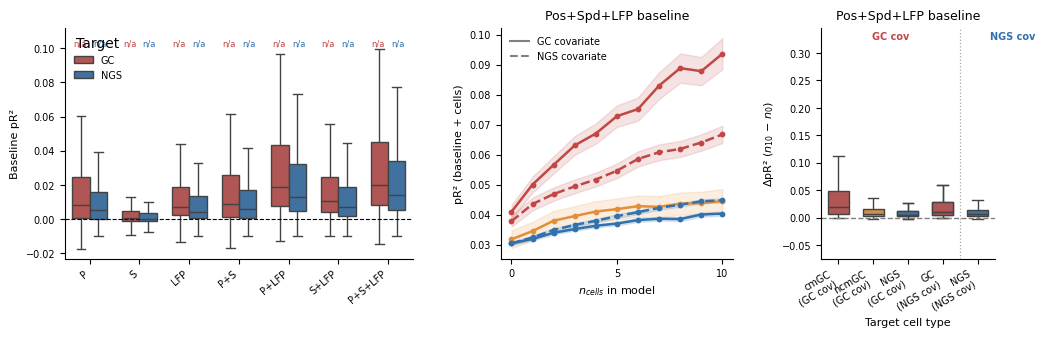

In [87]:
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# ── Flag ──────────────────────────────────────────────────────────────────────
run_lmm = False   # set True to compute LMM stats; False fills all p-values with NaN

# ── Collect data across all baselines ─────────────────────────────────────────
_gc_n0, _ngs_n0         = [], []
_gc_trend, _ngs_trend   = [], []
_gc_delta, _ngs_delta   = [], []

baseline_order = ['pos', 'speed', 'lfp', 'pos_speed', 'pos_lfp', 'speed_lfp', 'pos_speed_lfp']
for _baseline in baseline_order:
    _rd, _rd_ngs = make_random_data(data, _baseline)

    _n0 = (_rd[_rd['n_neurons'] == 0]
           .drop_duplicates(subset=['mouse', 'day', 'cluster_id'])
           .assign(baseline=_baseline))
    _gc_n0.append( _n0[_n0['tested_on'].isin(['cmGC', 'ncmGC'])])
    _ngs_n0.append(_n0[_n0['tested_on'] == 'NGS'])

    _gc_trend.append( _rd[    _rd['trained_on']     == 'GC' ].assign(baseline=_baseline))
    _ngs_trend.append(_rd_ngs[_rd_ngs['trained_on'] == 'NGS'].assign(baseline=_baseline))

    # Natural pairings
    _gc_nat  = compute_added_pR2_max(_rd,     'GC',  gc_groups)
    _ngs_nat = compute_added_pR2_max(_rd_ngs, 'NGS', ngs_groups)

    # Cross-predictions: only include if n_neurons=0 data exists for that target type
    try:
        _gc_cross = compute_added_pR2_max(_rd, 'GC', ngs_groups)
    except KeyError:
        _gc_cross = pd.DataFrame(columns=_gc_nat.columns)

    try:
        _ngs_cross = compute_added_pR2_max(_rd_ngs, 'NGS', gc_groups).assign(tested_on='GC')
    except KeyError:
        _ngs_cross = pd.DataFrame(columns=_ngs_nat.columns)

    _gc_delta.append(
        pd.concat([_gc_nat, _gc_cross], ignore_index=True).assign(baseline=_baseline))
    _ngs_delta.append(
        pd.concat([_ngs_cross, _ngs_nat], ignore_index=True).assign(baseline=_baseline))

gc_n0_all     = pd.concat(_gc_n0,    ignore_index=True)
ngs_n0_all    = pd.concat(_ngs_n0,   ignore_index=True)
gc_trend_all  = pd.concat(_gc_trend,  ignore_index=True)
ngs_trend_all = pd.concat(_ngs_trend, ignore_index=True)
gc_delta_all  = pd.concat(_gc_delta,  ignore_index=True)
ngs_delta_all = pd.concat(_ngs_delta, ignore_index=True)

# ── Stats ─────────────────────────────────────────────────────────────────────
_nan_groups   = lambda grps: {g: np.nan for g in grps}
_nan_pairwise = lambda grps: {(a, b): np.nan for a in grps for b in grps if a != b}

if run_lmm:
    col0_zero_gc  = zero_pvals_lmm(
        gc_n0_all[['mouse', 'day', 'cluster_id', 'pR2', 'baseline']]
        .rename(columns={'pR2': 'added_pR2', 'baseline': 'tested_on'}),
        baseline_order)
    col0_zero_ngs = zero_pvals_lmm(
        ngs_n0_all[['mouse', 'day', 'cluster_id', 'pR2', 'baseline']]
        .rename(columns={'pR2': 'added_pR2', 'baseline': 'tested_on'}),
        baseline_order)
    psl_lmm = all_lmm_results['pos_speed_lfp']
else:
    col0_zero_gc  = _nan_groups(baseline_order)
    col0_zero_ngs = _nan_groups(baseline_order)
    psl_lmm = {
        'pvals_gc':  _nan_pairwise(gc_groups),
        'gc_zero':   _nan_groups(gc_groups),
        'pvals_ngs': _nan_pairwise(ngs_groups),
        'ngs_zero':  _nan_groups(ngs_groups),
    }

# ── Helpers ────────────────────────────────────────────────────────────────────
def clip_pct(df, col):
    lo, hi = df[col].quantile(0.01), df[col].quantile(0.99)
    return df[df[col].between(lo, hi)]

def sig_marker(p):
    if p is None or (isinstance(p, float) and np.isnan(p)): return 'n/a'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def whisker_top(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    return series[series <= q3 + 1.5 * (q3 - q1)].max()

short_bl       = {'pos': 'P', 'speed': 'S', 'lfp': 'LFP', 'pos_speed': 'P+S',
                  'pos_lfp': 'P+LFP', 'speed_lfp': 'S+LFP', 'pos_speed_lfp': 'P+S+LFP'}
short_bl_order = [short_bl[b] for b in baseline_order]
cell_pal       = {'GC': '#c04744', 'NGS': '#3171ae'}

# ── 1×3 figure ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 3))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35, width_ratios=[3, 2, 1.5])

# ── Col 0 ─────────────────────────────────────────────────────────────────────
ax_n0 = fig.add_subplot(gs[0, 0])

gc_n0_plot  = clip_pct(gc_n0_all,  'pR2').assign(
    label=lambda d: d['baseline'].map(short_bl), cov_type='GC')
ngs_n0_plot = clip_pct(ngs_n0_all, 'pR2').assign(
    label=lambda d: d['baseline'].map(short_bl), cov_type='NGS')
n0_combined = pd.concat([gc_n0_plot, ngs_n0_plot], ignore_index=True)

sns.boxplot(data=n0_combined, x='label', y='pR2', hue='cov_type',
            palette=cell_pal, order=short_bl_order,
            width=0.7, showfliers=False, ax=ax_n0)
ax_n0.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax_n0.set_xlabel('')
ax_n0.set_ylabel('Baseline pR²', fontsize=8)
ax_n0.tick_params(axis='x', rotation=40, labelsize=7)
ax_n0.tick_params(axis='y', labelsize=7)
ax_n0.spines['top'].set_visible(False)
ax_n0.spines['right'].set_visible(False)
ax_n0.legend(title='Target', fontsize=7, frameon=False, loc='upper left')
for tick in ax_n0.get_xticklabels():
    tick.set_ha('right')

y_lim    = ax_n0.get_ylim()
y_ticks  = [t for t in ax_n0.get_yticks() if y_lim[0] <= t <= y_lim[1]]
y_top    = max(y_ticks) if y_ticks else y_lim[1]
tick_gap = (y_ticks[-1] - y_ticks[-2]) if len(y_ticks) >= 2 else (y_lim[1] - y_lim[0]) * 0.1
ax_n0.set_ylim(top=y_top + tick_gap * 0.6)
for i, bl in enumerate(baseline_order):
    ax_n0.text(i - 0.2, y_top, sig_marker(col0_zero_gc.get(bl, np.nan)),
               ha='center', va='bottom', fontsize=6, color=cell_pal['GC'])
    ax_n0.text(i + 0.2, y_top, sig_marker(col0_zero_ngs.get(bl, np.nan)),
               ha='center', va='bottom', fontsize=6, color=cell_pal['NGS'])

# ── Col 1 ─────────────────────────────────────────────────────────────────────
ax_tr = fig.add_subplot(gs[0, 1])

psl_gc_trend  = gc_trend_all[ gc_trend_all['baseline'] == 'pos_speed_lfp']
psl_ngs_trend = ngs_trend_all[ngs_trend_all['baseline'] == 'pos_speed_lfp']

for trend_df, ls in [(psl_gc_trend, '-'), (psl_ngs_trend, '--')]:
    for to in sorted(trend_df['tested_on'].unique()):
        b = (trend_df[trend_df['tested_on'] == to]
             .groupby('n_neurons')['pR2']
             .agg(['mean', 'sem'])
             .reset_index()
             .sort_values('n_neurons'))
        if b.empty:
            continue
        c = palette.get(to)
        ax_tr.plot(b['n_neurons'], b['mean'], color=c, linewidth=1.8, linestyle=ls)
        ax_tr.scatter(b['n_neurons'], b['mean'], s=10, color=c, zorder=3)
        ax_tr.fill_between(b['n_neurons'],
                           b['mean'] - b['sem'], b['mean'] + b['sem'],
                           color=c, alpha=0.15)

ax_tr.set_xlabel('$n_{cells}$ in model', fontsize=8)
ax_tr.set_ylabel('pR² (baseline + cells)', fontsize=8)
ax_tr.set_title('Pos+Spd+LFP baseline', fontsize=9)
ax_tr.set_xticks([0, 5, 10])
ax_tr.tick_params(labelsize=7)
ax_tr.spines['top'].set_visible(False)
ax_tr.spines['right'].set_visible(False)
ax_tr.legend(handles=[
    Line2D([0], [0], color='gray', linewidth=1.5, linestyle='-',  label='GC covariate'),
    Line2D([0], [0], color='gray', linewidth=1.5, linestyle='--', label='NGS covariate'),
], fontsize=7, frameon=False)

# ── Col 2: delta pR2 split by covariate type ──────────────────────────────────
ax_dlt = fig.add_subplot(gs[0, 2])

psl_gc_d  = clip_pct(gc_delta_all[ gc_delta_all['baseline']  == 'pos_speed_lfp'], 'added_pR2').copy()
psl_ngs_d = clip_pct(ngs_delta_all[ngs_delta_all['baseline'] == 'pos_speed_lfp'], 'added_pR2').copy()
psl_gc_d['label']  = psl_gc_d['tested_on']  + '\n(GC cov)'
psl_ngs_d['label'] = psl_ngs_d['tested_on'] + '\n(NGS cov)'

# Order: GC covariate section then NGS covariate section
# Only include boxes that have data (cross-predictions may be absent)
gc_box_order  = [g + '\n(GC cov)'  for g in gc_groups + ngs_groups]
ngs_box_order = ['GC\n(NGS cov)'] + [g + '\n(NGS cov)' for g in ngs_groups]
psl_combined  = pd.concat([psl_gc_d, psl_ngs_d], ignore_index=True)
existing      = set(psl_combined['label'].unique())
box_order     = [l for l in gc_box_order + ngs_box_order if l in existing]

label_palette = {lbl: palette.get(lbl.split('\n')[0], 'gray') for lbl in box_order}
all_zpvals    = {}
for g in gc_groups + ngs_groups:
    all_zpvals[f'{g}\n(GC cov)']  = psl_lmm['gc_zero'].get(g, np.nan)
for g in ngs_groups:
    all_zpvals[f'{g}\n(NGS cov)'] = psl_lmm['ngs_zero'].get(g, np.nan)

group_w_tops = {lbl: whisker_top(psl_combined[psl_combined['label'] == lbl]['added_pR2'])
                for lbl in box_order
                if not psl_combined[psl_combined['label'] == lbl].empty}
max_w_top  = max(group_w_tops.values()) if group_w_tops else 0.1

step_gc    = 0.055
n_pairs_gc = len(gc_groups) * (len(gc_groups) - 1) / 2
y_sig      = max_w_top + 0.01
ylim_top   = y_sig + step_gc * n_pairs_gc + 0.06
ylim       = (-0.075, ylim_top)
y_range    = ylim[1] - ylim[0]

sns.boxplot(data=psl_combined, x='label', y='added_pR2',
            palette=label_palette, order=box_order,
            width=0.6, showfliers=False, ax=ax_dlt)
ax_dlt.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_dlt.set_ylim(*ylim)

if run_lmm:
    add_sig_bars(ax_dlt, gc_groups, psl_lmm['pvals_gc'], y_start=y_sig, step=step_gc)

for i, lbl in enumerate(box_order):
    if lbl not in group_w_tops:
        continue
    p = all_zpvals.get(lbl, np.nan)
    if not (isinstance(p, float) and np.isnan(p)):
        ax_dlt.text(i, group_w_tops[lbl] + y_range * 0.02, f'p={p:.2g}',
                    ha='center', va='bottom', fontsize=7)

n_gc_boxes  = len([l for l in gc_box_order  if l in existing])
n_ngs_boxes = len([l for l in ngs_box_order if l in existing])
if n_gc_boxes > 0 and n_ngs_boxes > 0:
    ax_dlt.axvline(n_gc_boxes - 0.5, color='gray', linestyle=':', linewidth=0.9, alpha=0.7)
    ax_dlt.text(n_gc_boxes / 2 - 0.5,               ylim[1] * 0.98, 'GC cov',
                ha='center', va='top', fontsize=7, fontweight='bold', color=cell_pal['GC'])
    ax_dlt.text(n_gc_boxes + n_ngs_boxes / 2 - 0.5, ylim[1] * 0.98, 'NGS cov',
                ha='center', va='top', fontsize=7, fontweight='bold', color=cell_pal['NGS'])

ax_dlt.set_xlabel('Target cell type', fontsize=8)
ax_dlt.set_ylabel('$\\Delta$pR² ($n_{10}$ − $n_0$)', fontsize=8)
ax_dlt.set_title('Pos+Spd+LFP baseline', fontsize=9)
ax_dlt.tick_params(axis='x', labelsize=7, rotation=30)
ax_dlt.tick_params(axis='y', labelsize=7)
ax_dlt.spines['top'].set_visible(False)
ax_dlt.spines['right'].set_visible(False)
for tick in ax_dlt.get_xticklabels():
    tick.set_ha('right')

plt.savefig(os.path.join(out_dir, 'all_baselines_psl_detail_1x3_box.pdf'), bbox_inches='tight', dpi=300)
plt.show()


In [52]:
# Summary table of LMM p-values across all baselines
rows = []
for baseline, res in all_lmm_results.items():
    label = baseline_labels[baseline]
    for (g1, g2), pval in res['pvals_gc'].items():
        rows.append({'baseline': label, 'covariate': 'GC',
                     'group1': g1, 'group2': g2, 'comparison': 'pairwise (max n)', 'pval': pval})
    for g, pval in res['gc_zero'].items():
        rows.append({'baseline': label, 'covariate': 'GC',
                     'group1': g, 'group2': 'zero', 'comparison': 'vs zero (max n)', 'pval': pval})
    for (g1, g2), pval in res['pvals_ngs'].items():
        rows.append({'baseline': label, 'covariate': 'NGS',
                     'group1': g1, 'group2': g2, 'comparison': 'pairwise (max n)', 'pval': pval})
    for g, pval in res['ngs_zero'].items():
        rows.append({'baseline': label, 'covariate': 'NGS',
                     'group1': g, 'group2': 'zero', 'comparison': 'vs zero (max n)', 'pval': pval})

lmm_summary = pd.DataFrame(rows)
lmm_summary.to_csv(os.path.join(out_dir, 'lmm_pvals_all_baselines.csv'), index=False)
display(lmm_summary)

,baseline,covariate,group1,group2,comparison,pval
0,Position,GC,cmGC,ncmGC,pairwise (max n),3.939179e-06
1,Position,GC,cmGC,NGS,pairwise (max n),5.401212e-45
2,Position,GC,ncmGC,NGS,pairwise (max n),5.501700e-01
3,Position,GC,cmGC,zero,vs zero (max n),1.839213e-31
4,Position,GC,ncmGC,zero,vs zero (max n),5.890178e-11
...,...,...,...,...,...,...
58,Position + Speed + LFP,GC,ncmGC,zero,vs zero (max n),3.874460e-12
59,Position + Speed + LFP,GC,NGS,zero,vs zero (max n),2.263597e-14
60,Position + Speed + LFP,NGS,GC,NGS,pairwise (max n),2.966870e-02
61,Position + Speed + LFP,NGS,GC,zero,vs zero (max n),1.491625e-16


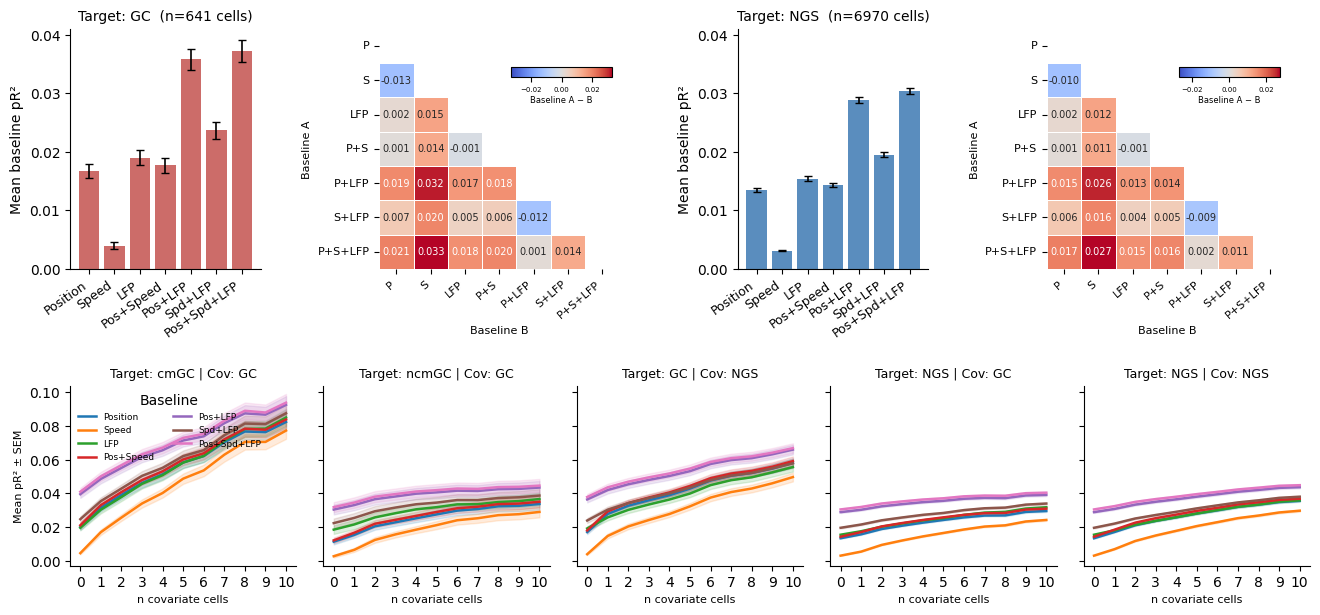

In [53]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load ─────────────────────────────────────────────────────────────────────
data = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/xgboost_cell_number_assay_master.csv')

baseline_order = ['pos', 'speed', 'lfp', 'pos_speed', 'pos_lfp', 'speed_lfp', 'pos_speed_lfp']
baseline_labels = {
    'pos': 'Position', 'speed': 'Speed', 'lfp': 'LFP',
    'pos_speed': 'Pos+Speed', 'pos_lfp': 'Pos+LFP',
    'speed_lfp': 'Spd+LFP', 'pos_speed_lfp': 'Pos+Spd+LFP',
}
short_labels = {
    'pos': 'P', 'speed': 'S', 'lfp': 'LFP',
    'pos_speed': 'P+S', 'pos_lfp': 'P+LFP',
    'speed_lfp': 'S+LFP', 'pos_speed_lfp': 'P+S+LFP',
}
label_order       = [baseline_labels[b] for b in baseline_order]
short_label_order = [short_labels[b]    for b in baseline_order]

# ── Infer cell types ──────────────────────────────────────────────────────────
cluster_types = (
    data.groupby(['mouse', 'day', 'target_cluster_id'])['covariate_type']
    .apply(lambda x: set(x)).reset_index()
)
cluster_types['cell_type_g'] = cluster_types['covariate_type'].apply(
    lambda s: 'cmGC' if 'cmGC' in s else ('ncmGC' if 'ncmGC' in s else 'NGS')
)
cluster_types['cell_type_c'] = cluster_types['cell_type_g'].apply(
    lambda t: 'GC' if t in ('cmGC', 'ncmGC') else 'NGS'
)
ct = cluster_types[['mouse', 'day', 'target_cluster_id', 'cell_type_g', 'cell_type_c']]

# ── n=0 pivots ────────────────────────────────────────────────────────────────
df_n0 = (
    data[data['n_covariate_cells'] == 0]
    .drop_duplicates(subset=['mouse', 'day', 'target_cluster_id', 'baseline'])
    .merge(ct, on=['mouse', 'day', 'target_cluster_id'])
)
df_n0['cell_uid'] = (df_n0['mouse'].astype(str) + '_' +
                     df_n0['day'].astype(str)    + '_' +
                     df_n0['target_cluster_id'].astype(str))

pivot_c = df_n0.pivot_table(
    index=['cell_uid', 'cell_type_c'], columns='baseline', values='pR2_cv'
)[baseline_order].dropna()
pivots_c = {t: pivot_c.xs(t, level='cell_type_c')
            for t in ['GC', 'NGS']
            if t in pivot_c.index.get_level_values('cell_type_c')}

pivot_g = df_n0.pivot_table(
    index=['cell_uid', 'cell_type_g'], columns='baseline', values='pR2_cv'
)[baseline_order].dropna()
pivots_g = {t: pivot_g.xs(t, level='cell_type_g')
            for t in ['cmGC', 'ncmGC', 'NGS']
            if t in pivot_g.index.get_level_values('cell_type_g')}

# ── Trend data (all n) ────────────────────────────────────────────────────────
uid_map   = df_n0[['mouse', 'day', 'target_cluster_id', 'cell_uid']].drop_duplicates('cell_uid')
valid_g   = pivot_g.reset_index()[['cell_uid', 'cell_type_g']].merge(uid_map, on='cell_uid')
trend_raw = (
    data.merge(valid_g[['mouse', 'day', 'target_cluster_id', 'cell_type_g']],
               on=['mouse', 'day', 'target_cluster_id'])
    .assign(cell_type_c=lambda df: df['cell_type_g'].apply(
        lambda t: 'GC' if t in ('cmGC', 'ncmGC') else t
    ))
)

cov_types     = sorted(trend_raw['covariate_cell_type'].unique())
gc_cov_types  = [c for c in cov_types if 'NGS' not in str(c)]
ngs_cov_types = [c for c in cov_types if 'NGS' in str(c)]

def get_trend(target_col, target_val, cov_filter):
    mask = ((trend_raw[target_col] == target_val) &
            (trend_raw['covariate_cell_type'].isin(cov_filter)))
    return (
        trend_raw[mask]
        .groupby(['baseline', 'n_covariate_cells'])['pR2_cv']
        .agg(mean='mean', sem=lambda x: x.sem())
        .reset_index()
    )

# ── Helpers ───────────────────────────────────────────────────────────────────
cell_palette     = {'GC': '#c04744', 'NGS': '#3171ae'}
baseline_palette = dict(zip(baseline_order, sns.color_palette('tab10', len(baseline_order))))

def plot_triangle_heatmap(ax, ct_piv, title):
    n  = len(baseline_order)
    dm = np.array([[(ct_piv[br] - ct_piv[bc]).mean()
                    for bc in baseline_order]
                   for br in baseline_order])
    mask = np.triu(np.ones((n, n), dtype=bool))
    vmax = np.abs(dm[~mask]).max()
    sns.heatmap(
        pd.DataFrame(dm, index=short_label_order, columns=short_label_order),
        ax=ax, mask=mask,
        cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
        annot=True, fmt='.3f', annot_kws={'size': 7},
        linewidths=0.4, linecolor='white',
        cbar=False, square=True,
    )
    cbar_ax = ax.inset_axes([0.55, 0.80, 0.42, 0.04])
    norm = mpl.colors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    sm   = mpl.cm.ScalarMappable(cmap='coolwarm', norm=norm)
    sm.set_array([])
    cbar = ax.figure.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Baseline A − B', fontsize=6, labelpad=2)
    cbar_ax.tick_params(labelsize=5)
    ax.set_title(title, pad=8, fontsize=9)
    ax.set_xlabel('Baseline B', fontsize=8)
    ax.set_ylabel('Baseline A', fontsize=8)
    ax.tick_params(axis='x', rotation=40, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)
    for tick in ax.get_xticklabels():
        tick.set_ha('right')

def plot_trend_line(ax, td, title, show_legend=False, show_ylabel=True):
    if td.empty:
        ax.set_visible(False); return
    for baseline in baseline_order:
        b = td[td['baseline'] == baseline].sort_values('n_covariate_cells')
        if b.empty:
            continue
        color = baseline_palette[baseline]
        ax.plot(b['n_covariate_cells'], b['mean'], color=color,
                linewidth=1.8, label=baseline_labels[baseline])
        ax.fill_between(b['n_covariate_cells'],
                        b['mean'] - b['sem'], b['mean'] + b['sem'],
                        color=color, alpha=0.15)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('n covariate cells', fontsize=8)
    ax.set_ylabel('Mean pR² ± SEM' if show_ylabel else '', fontsize=8)
    ax.set_xticks(range(0, 11))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if show_legend:
        ax.legend(title='Baseline', frameon=False, fontsize=6.5, loc='upper left', ncol=2)

# ── Figure: 2 subfigure rows ──────────────────────────────────────────────────
fig     = plt.figure(figsize=(16, 6))
subfigs = fig.subfigures(2, 1, height_ratios=[2, 1.5], hspace=0.2)

# ── Row 0: [bar_GC | hm_GC | bar_NGS | hm_NGS] ───────────────────────────────
gs0 = subfigs[0].add_gridspec(1, 4, wspace=0.4, width_ratios=[1, 1.5, 1, 1.5])
ax_gc_bar  = subfigs[0].add_subplot(gs0[0, 0])
ax_gc_hm   = subfigs[0].add_subplot(gs0[0, 1])
ax_ngs_bar = subfigs[0].add_subplot(gs0[0, 2])
ax_ngs_hm  = subfigs[0].add_subplot(gs0[0, 3])
ax_ngs_bar.sharey(ax_gc_bar)

for ax, ttype in [(ax_gc_hm, 'GC'), (ax_ngs_hm, 'NGS')]:
    ct_piv = pivots_c.get(ttype)
    if ct_piv is not None:
        plot_triangle_heatmap(ax, ct_piv, '')

x = np.arange(len(label_order))
for ax, ttype in [(ax_gc_bar, 'GC'), (ax_ngs_bar, 'NGS')]:
    ct_piv = pivots_c.get(ttype)
    if ct_piv is None:
        ax.set_visible(False); continue
    ax.bar(x, ct_piv.mean(), yerr=ct_piv.sem(),
           color=cell_palette[ttype], alpha=0.8,
           error_kw=dict(elinewidth=1.2, capsize=3))
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(label_order, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Mean baseline pR²')
    ax.set_title(f'Target: {ttype}  (n={len(ct_piv)} cells)', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Row 1: GC targets first, then NGS targets ────────────────────────────────
trend_items = [
    ('cmGC',  'cell_type_g', gc_cov_types,  'Target: cmGC | Cov: GC'),
    ('ncmGC', 'cell_type_g', gc_cov_types,  'Target: ncmGC | Cov: GC'),
    ('GC',    'cell_type_c', ngs_cov_types, 'Target: GC | Cov: NGS'),
    ('NGS',   'cell_type_g', gc_cov_types,  'Target: NGS | Cov: GC'),
    ('NGS',   'cell_type_g', ngs_cov_types, 'Target: NGS | Cov: NGS'),
]

gs1  = subfigs[1].add_gridspec(1, 5, wspace=0.12)
axes = [subfigs[1].add_subplot(gs1[0, i]) for i in range(5)]

for ax in axes[1:]:
    ax.sharey(axes[0])

for col_i, (ax, (tval, tcol, cov_f, title)) in enumerate(zip(axes, trend_items)):
    plot_trend_line(ax, get_trend(tcol, tval, cov_f), title,
                    show_legend=(col_i == 0), show_ylabel=(col_i == 0))
    if col_i > 0:
        ax.tick_params(labelleft=False)

plt.savefig(
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/baselines/baseline_summary_and_delta_heatmap.pdf',
    bbox_inches='tight', dpi=300
)
plt.show()
